In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

sns.set_style("whitegrid")

In [2]:
X_test = pd.read_csv(
    "/content/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "/content/y_test.csv"
)

y_test = y_test.values.ravel()


print(X_test.shape)
print(y_test.shape)

(240, 19)
(240,)


In [3]:
log_model = joblib.load(
    "/content/logistic_regression_model.pkl"
)


rf_model = joblib.load(
    "/content/random_forest_model.pkl"
)


print("Models loaded successfully")

Models loaded successfully


In [4]:
log_prediction = log_model.predict(
    X_test
)


log_probability = log_model.predict_proba(
    X_test
)[:,1]

In [5]:
rf_prediction = rf_model.predict(
    X_test
)


rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

In [6]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            log_prediction
        ),

        accuracy_score(
            y_test,
            rf_prediction
        )
    ],


    "Precision":[

        precision_score(
            y_test,
            log_prediction
        ),

        precision_score(
            y_test,
            rf_prediction
        )
    ],


    "Recall":[

        recall_score(
            y_test,
            log_prediction
        ),

        recall_score(
            y_test,
            rf_prediction
        )
    ],


    "F1 Score":[

        f1_score(
            y_test,
            log_prediction
        ),

        f1_score(
            y_test,
            rf_prediction
        )
    ],


    "ROC-AUC":[

        roc_auc_score(
            y_test,
            log_probability
        ),

        roc_auc_score(
            y_test,
            rf_probability
        )
    ]

})


comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.991667,0.958333,0.958333,0.958333,0.998457
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
comparison.to_csv(
    "model_comparison_results.csv",
    index=False
)


print("Comparison saved")

Comparison saved


In [8]:
print(
    "Logistic Regression Report\n"
)


print(
    classification_report(
        y_test,
        log_prediction
    )
)

Logistic Regression Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       0.96      0.96      0.96        24

    accuracy                           0.99       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.99      0.99      0.99       240



In [9]:
print(
    "Random Forest Report\n"
)


print(
    classification_report(
        y_test,
        rf_prediction
    )
)

Random Forest Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00        24

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



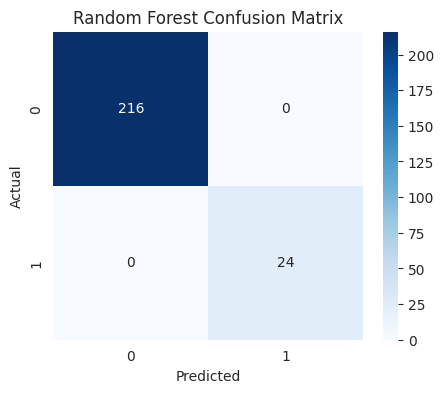

In [10]:
cm = confusion_matrix(
    y_test,
    rf_prediction
)


plt.figure(figsize=(5,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

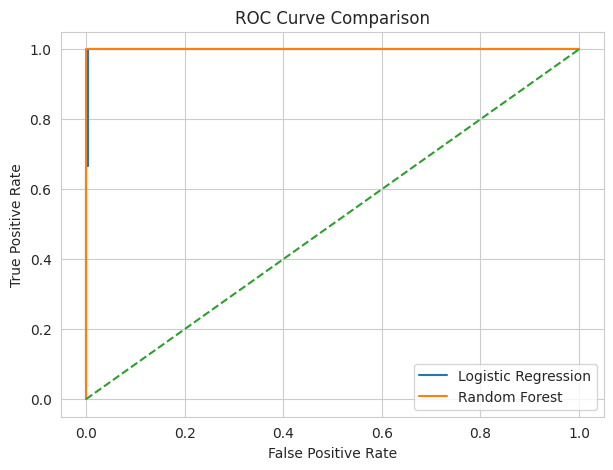

In [11]:
log_fpr, log_tpr, _ = roc_curve(
    y_test,
    log_probability
)


rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)



plt.figure(figsize=(7,5))


plt.plot(
    log_fpr,
    log_tpr,
    label="Logistic Regression"
)


plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend()

plt.show()

In [12]:
feature_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance":
    rf_model.feature_importances_

})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance

,Feature,Importance
3,3,0.388830
6,6,0.184237
1,1,0.174925
0,0,0.143201
2,2,0.077419
5,5,0.011150
4,4,0.003881
16,16,0.003734
13,13,0.003372
17,17,0.001645


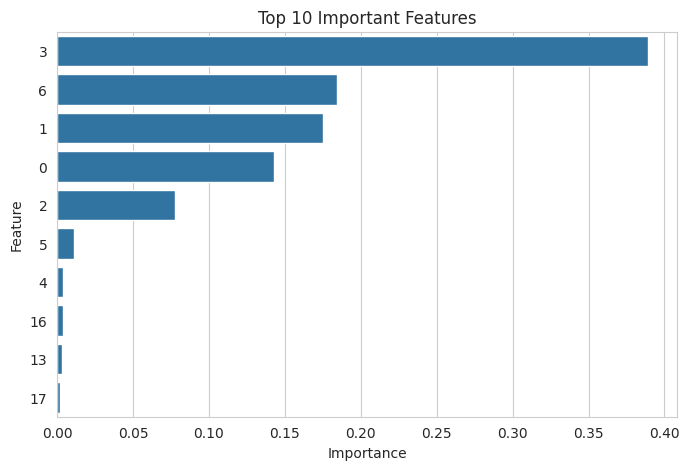

In [13]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)


plt.title(
    "Top 10 Important Features"
)


plt.show()

## Conclusion

A supervised machine learning pipeline was developed for transaction risk classification.

The dataset was preprocessed, class imbalance was handled using SMOTE, and Logistic Regression and Random Forest models were evaluated.

Performance was compared using accuracy, precision, recall, F1-score and ROC-AUC metrics.

Random Forest achieved the strongest performance, showing its ability to capture complex relationships within transaction behaviour.

The project demonstrates the importance of handling imbalanced classification problems and selecting appropriate evaluation metrics beyond accuracy.